Figura: Circulo
Vertices: 8
Area: 248839.0
Hu moments: [  0.79802782   4.91386974   6.84868579  10.63992097 -11.99999999
 -11.97154209  11.99999998]
----------------------------------------


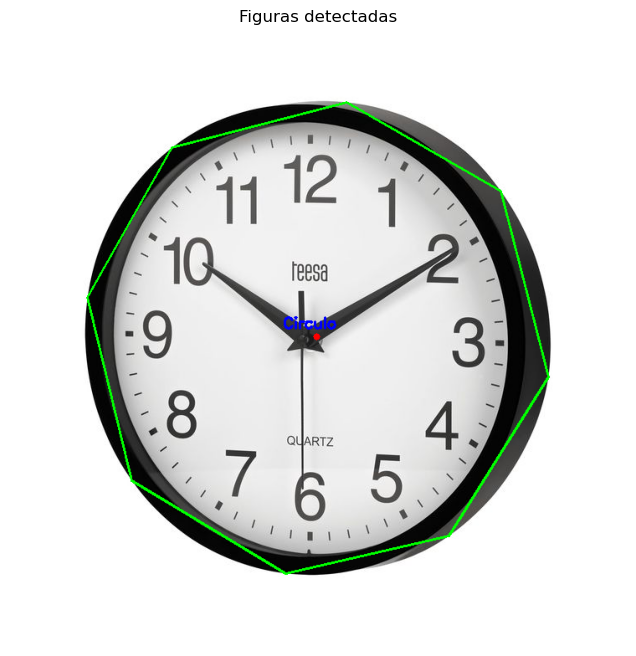

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = "reloj3.jpg"
area_minima = 500

img = cv2.imread(ruta_imagen)
if img is None:
    raise FileNotFoundError("No se pudo abrir la imagen")

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 50, 255])
mask_white = cv2.inRange(hsv, lower_white, upper_white)

thresh = cv2.bitwise_not(mask_white)

kernel = np.ones((3, 3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

salida = img.copy()

def clasificar(approx, contour):
    v = len(approx)

    if v == 3:
        return "Triangulo"
    elif v == 4:
        x, y, w, h = cv2.boundingRect(approx)
        ratio = w / float(h)
        if 0.90 <= ratio <= 1.10:
            return "Cuadrado"
        return "Rectangulo"
    elif v > 4:
        area = cv2.contourArea(contour)
        perimetro = cv2.arcLength(contour, True)
        if perimetro == 0:
            return "Otro"
        circularidad = 4 * np.pi * area / (perimetro * perimetro)
        if circularidad > 0.75:
            return "Circulo"
        return "Otro"
    else:
        return "Otro"

for c in contours:
    area = cv2.contourArea(c)
    if area < area_minima:
        continue

    perimetro = cv2.arcLength(c, True)
    epsilon = 0.02 * perimetro
    approx = cv2.approxPolyDP(c, epsilon, True)

    figura = clasificar(approx, c)

    M = cv2.moments(c)
    hu = cv2.HuMoments(M).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    cv2.drawContours(salida, [approx], -1, (0, 255, 0), 2)
    cv2.circle(salida, (cx, cy), 4, (0, 0, 255), -1)
    cv2.putText(salida, figura, (cx - 40, cy - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    print("Figura:", figura)
    print("Vertices:", len(approx))
    print("Area:", area)
    print("Hu moments:", hu_log)
    print("-" * 40)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Figuras detectadas")
plt.show()